# Notebook 01: Análise Geral do Acervo Booklog

O objetivo é compreender a distribuição básica do catálogo de livros disponíveis no dataset. Analisamos os gêneros literários, autores, ano de publicação e o volume das avaliações, para identificar o perfil principal das obras que alimentarão o sistema de recomendação.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("datasets/books.csv")

df.head(10)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0
6,9780006353287,0006353282,An Autobiography,NaN,Agatha Christie,"Authors, English",http://books.google.com/books/content?id=c49GQ...,Donation.,1977.0,4.27,560.0,3975.0
7,9780006380832,0006380832,Empires of the Monsoon,A History of the Indian Ocean and Its Invaders,Richard Hall,"Africa, East",http://books.google.com/books/content?id=MuPEQ...,Until Vasco da Gama discovered the sea-route t...,1998.0,4.41,608.0,65.0
8,9780006470229,000647022X,The Gap Into Madness,Chaos and Order,Stephen R. Donaldson,"Hyland, Morn (Fictitious character)",http://books.google.com/books/content?id=4oXav...,A new-cover reissue of the fourth book in the ...,1994.0,4.15,743.0,103.0
9,9780006472612,0006472613,Master of the Game,NaN,Sidney Sheldon,Adventure stories,http://books.google.com/books/content?id=TkTYp...,Kate Blackwell is an enigma and one of the mos...,1982.0,4.11,489.0,43540.0


# 1. Os gêneros mais presentes no banco de dados.

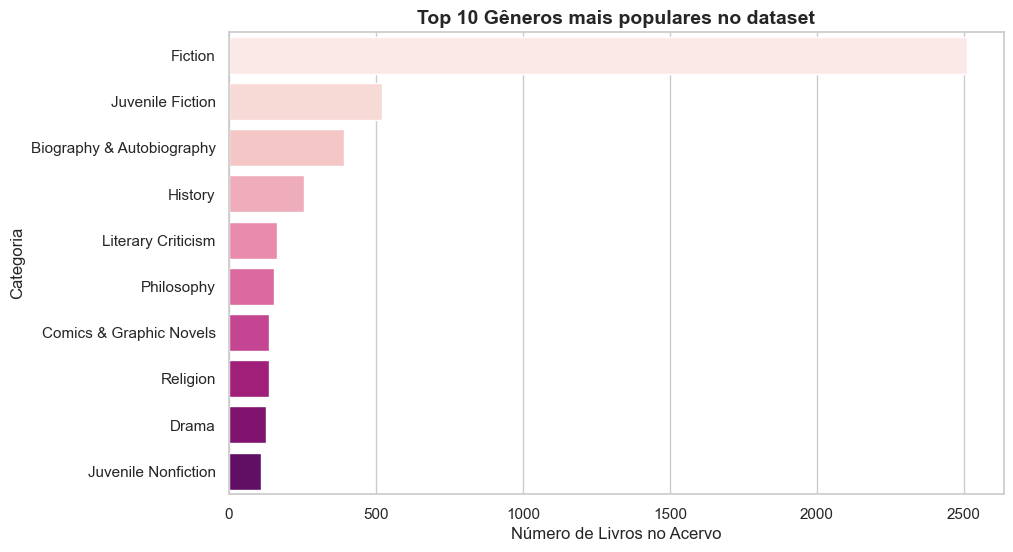

In [4]:
plt.figure(figsize=(10, 6))
top_categorias = df['categories'].value_counts().head(10)

pink_shades = ["#FFC0CB", "#FFB6C1", "#FF69B4", "#FF1493"]
sns.barplot(y=top_categorias.index, x=top_categorias.values, hue=top_categorias.index, palette="RdPu", legend=False)

plt.title('Top 10 Gêneros mais populares no dataset', fontsize=14, fontweight='bold')
plt.xlabel('Número de Livros no Acervo')
plt.ylabel('Categoria')
plt.show()

# 2. Autores com mais livros no acervo.
O objetivo é entender se o catálogo é pulverizado ou concentrado em grandes nomes da literatura.

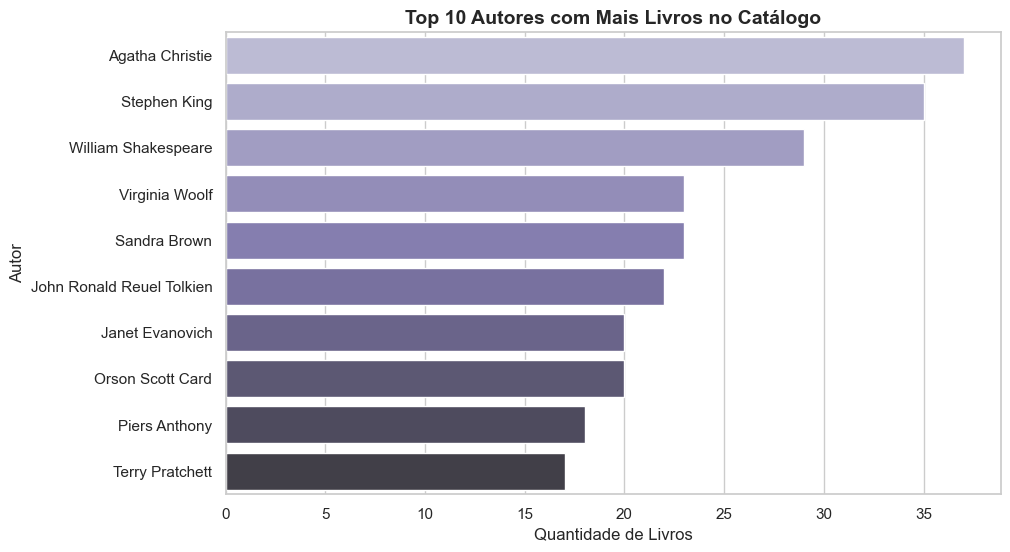

In [5]:
plt.figure(figsize=(10, 6))

top_autores = df['authors'].value_counts().head(10)

sns.barplot(y=top_autores.index, x=top_autores.values, hue=top_autores.index, palette="Purples_d")

plt.title('Top 10 Autores com Mais Livros no Catálogo', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Livros')
plt.ylabel('Autor')
plt.show()

# 3. Distribuição do Ano de Publicação
Analise da "idade" da nossa biblioteca.

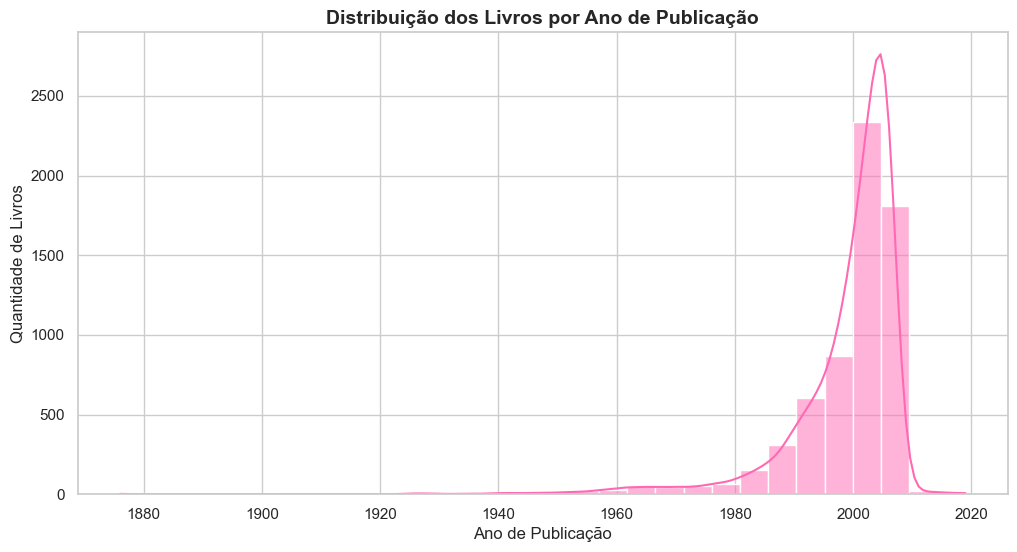

In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='published_year', bins=30, color='#FF69B4', kde=True)

plt.title('Distribuição dos Livros por Ano de Publicação', fontsize=14, fontweight='bold')
plt.xlabel('Ano de Publicação')
plt.ylabel('Quantidade de Livros')
plt.show()

# 4. Dispersão de Engajamento
O intuito é verificar a discrepância da popularidade entre os livros.

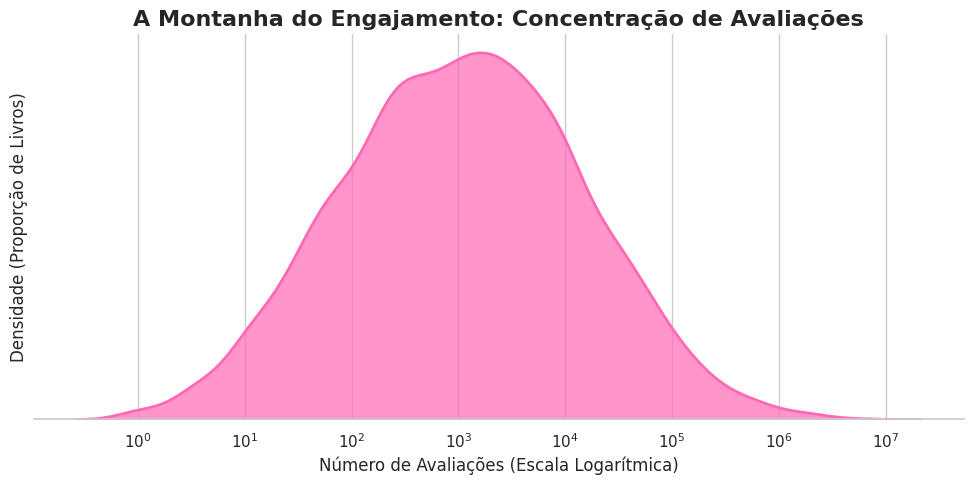

In [ ]:
plt.figure(figsize=(12, 5))

df_engajamento = df[df['ratings_count'] > 0]

sns.kdeplot(data=df_engajamento, x='ratings_count', log_scale=True, fill=True, color="#FF69B4", alpha=0.7, linewidth=2)

plt.title('A Montanha do Engajamento: Concentração de Avaliações', fontsize=16, fontweight='bold')
plt.xlabel('Número de Avaliações (Escala Logarítmica)', fontsize=12)
plt.ylabel('Densidade (Proporção de Livros)', fontsize=12)

sns.despine(left=True)
plt.yticks([])

plt.show()

# 5. Distribuição das Notas
O objetivo é analisar a curva de distribuição que nos mostrará se a maior parte dos livros possui notas medianas, ou se existe uma tendência a notas altas ou baixas.

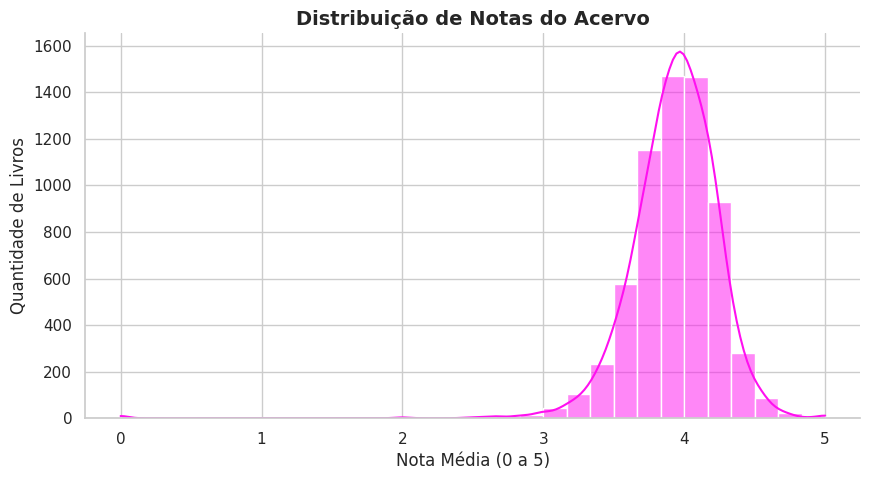

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='average_rating', bins=30, kde=True, color='#FF10F0', edgecolor='white')

plt.title('Distribuição de Notas do Acervo', fontsize=14, fontweight='bold')
plt.xlabel('Nota Média (0 a 5)', fontsize=12)
plt.ylabel('Quantidade de Livros', fontsize=12)

sns.despine()
plt.show()

# 6. Distribuição do Número de Páginas

Analise dos tamanhos das obras presentes no dataset, se os livros tendem a ser curtos, ou obras grandes.

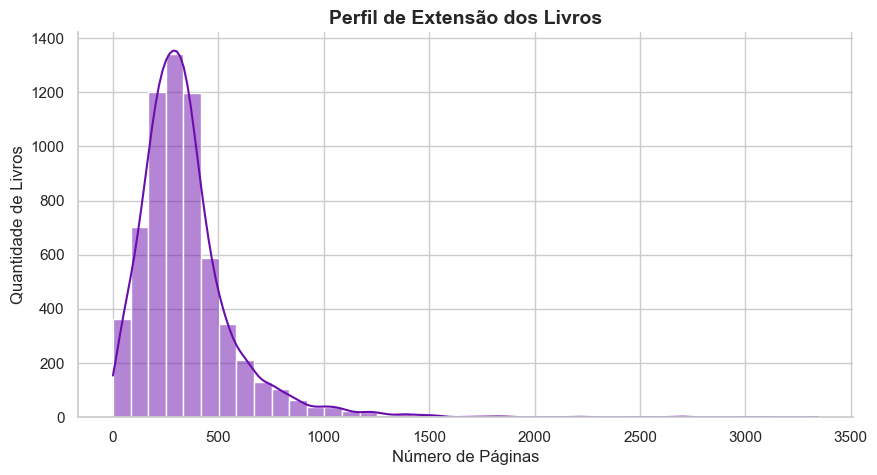

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='num_pages', bins=40, kde=True, color='#6A0DAD', edgecolor='white')

plt.title('Perfil de Extensão dos Livros', fontsize=14, fontweight='bold')
plt.xlabel('Número de Páginas', fontsize=12)
plt.ylabel('Quantidade de Livros', fontsize=12)

sns.despine()
plt.show()